In [1]:
import pandas as pd 
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
conn = sqlite3.connect("retail.db")

In [ ]:
query="""
select * from transactions"""
df=pd.read_sql(query,conn)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [30]:
query= """ 
select 
    t.CustomerID,
    julianday(j.max_date) - julianday(max(t.InvoiceDate)) as recency,
    count(distinct t.InvoiceNo) as frequency,
    round(sum(t.Revenue), 2) as monetary
from transactions t
cross join (
    select max(InvoiceDate) as max_date
    from transactions
) j
group by t.CustomerID
order by monetary desc;
"""
df_rfm = pd.read_sql(query,conn)
df_rfm["recency"] = df_rfm["recency"].astype(int)
df_rfm 

,CustomerID,recency,frequency,monetary
0,14646,1,72,279138.02
1,18102,0,60,259657.30
2,17450,7,46,194550.79
3,16446,0,2,168472.50
4,14911,0,199,140450.72
...,...,...,...,...
4329,16878,83,1,13.30
4330,17956,248,1,12.75
4331,14792,63,1,6.20
4332,16454,63,1,5.90


In [12]:
df_rfm['r_score'] = pd.qcut(df_rfm['recency'], q=5, 
                             labels=[5, 4, 3, 2, 1])

 
df_rfm['f_score'] = pd.qcut(df_rfm['frequency'].rank(method='first'), q=5, 
                             labels=[1, 2, 3, 4, 5])
 
df_rfm['m_score'] = pd.qcut(df_rfm['monetary'].rank(method='first'), q=5, 
                             labels=[1, 2, 3, 4, 5])
 
df_rfm['r_score'] = df_rfm['r_score'].astype(int)
df_rfm['f_score'] = df_rfm['f_score'].astype(int)
df_rfm['m_score'] = df_rfm['m_score'].astype(int)
 
df_rfm['rfm_score'] = (df_rfm['r_score'] + 
                        df_rfm['f_score'] + 
                        df_rfm['m_score']) / 3

print(df_rfm.head(10))

   CustomerID  recency  frequency   monetary  r_score  f_score  m_score  \
0       14646        1         72  279138.02        5        5        5   
1       18102        0         60  259657.30        5        5        5   
2       17450        7         46  194550.79        5        5        5   
3       16446        0          2  168472.50        5        2        5   
4       14911        0        199  140450.72        5        5        5   
5       12415       23         20  124564.53        4        5        5   
6       14156        9         55  117379.63        5        5        5   
7       17511        2         31   91062.38        5        5        5   
8       12346      325          1   77183.60        1        1        5   
9       16029       38         62   72882.09        3        5        5   

   rfm_score  
0   5.000000  
1   5.000000  
2   5.000000  
3   4.000000  
4   5.000000  
5   4.666667  
6   5.000000  
7   5.000000  
8   2.333333  
9   4.333333  


In [14]:
import numpy as np
import matplotlib.pyplot as plt

df_rfm["recency"] = df_rfm["recency"].astype(int)


conditions = [
    (df_rfm['r_score'] >= 4) & (df_rfm['f_score'] >= 4) & (df_rfm['m_score'] >= 4),
    (df_rfm['r_score'] >= 3) & (df_rfm['f_score'] >= 3) & (df_rfm['m_score'] >= 3),
    (df_rfm['r_score'] >= 4) & (df_rfm['f_score'] <= 2),
    (df_rfm['r_score'] <= 2) & (df_rfm['f_score'] >= 3) & (df_rfm['m_score'] >= 3),
    (df_rfm['r_score'] <= 2) & (df_rfm['f_score'] >= 4) & (df_rfm['m_score'] >= 4),
    (df_rfm['r_score'] <= 1) & (df_rfm['f_score'] <= 2) & (df_rfm['m_score'] <= 2),
    (df_rfm['m_score'] >= 4) & (df_rfm['f_score'] <= 2)
]

choices = [
    'VIP',
    '충성 고객',
    '신규 고객',
    '이탈 위험 고객',
    '놓치면 안 되는 고객',
    '이탈 고객',
    '고액 단발 고객'
]

df_rfm['세그먼트'] = np.select(conditions, choices, default='일반 고객')


print(df_rfm['세그먼트'].value_counts())

세그먼트
일반 고객       1205
VIP          913
충성 고객        765
이탈 고객        539
이탈 위험 고객     419
신규 고객        316
고액 단발 고객     177
Name: count, dtype: int64


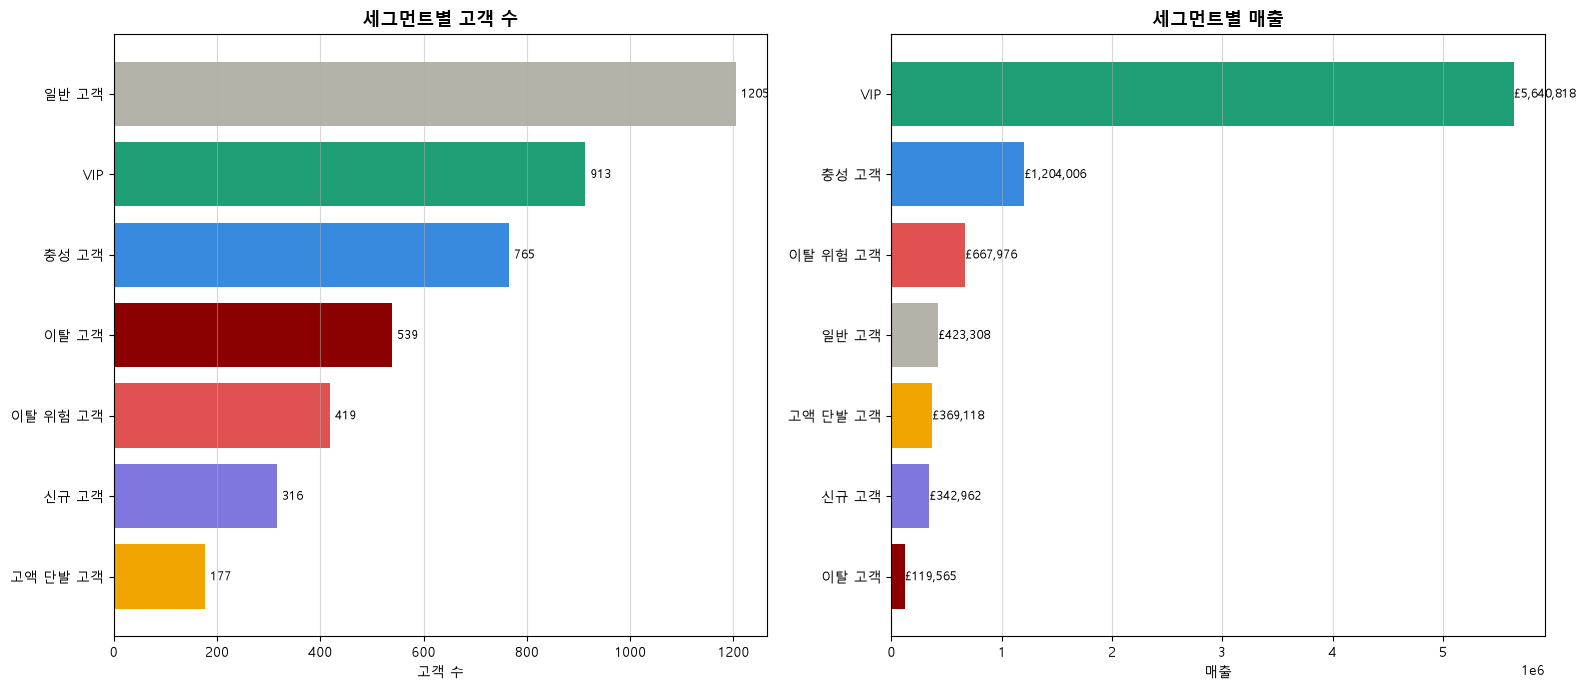

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Malgun Gothic'  
plt.rcParams['axes.unicode_minus'] = False   


fig, axes = plt.subplots(1, 2, figsize=(16, 7))


colors = {
    'VIP': '#1D9E75',
    '충성 고객': '#378ADD',
    '신규 고객': '#7F77DD',
    '일반 고객': '#B4B2A9',
    '고액 단발 고객': '#F0A500',
    '이탈 위험 고객': '#E05252',
    '이탈 고객': '#8B0000'
}



segment_counts = df_rfm['세그먼트'].value_counts()
segment_revenue = df_rfm.groupby('세그먼트')['monetary'].sum().sort_values(ascending=False)



bar_colors = [colors.get(s, '#999999') for s in segment_counts.index]

axes[0].barh(segment_counts.index, segment_counts.values, color=bar_colors)

for i, value in enumerate(segment_counts.values):
    axes[0].text(value + 10, i, str(value), va='center', fontsize=9)

axes[0].set_title('세그먼트별 고객 수', fontsize=13, fontweight='bold')
axes[0].set_xlabel('고객 수')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.5)


bar_colors_rev = [colors.get(s, '#999999') for s in segment_revenue.index]

axes[1].barh(segment_revenue.index, segment_revenue.values, color=bar_colors_rev)

for i, value in enumerate(segment_revenue.values):
    axes[1].text(value + 1000, i, f'£{value:,.0f}', va='center', fontsize=9)

axes[1].set_title('세그먼트별 매출', fontsize=13, fontweight='bold')
axes[1].set_xlabel('매출')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.5)

plt.tight_layout()
plt.savefig('imgs/rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

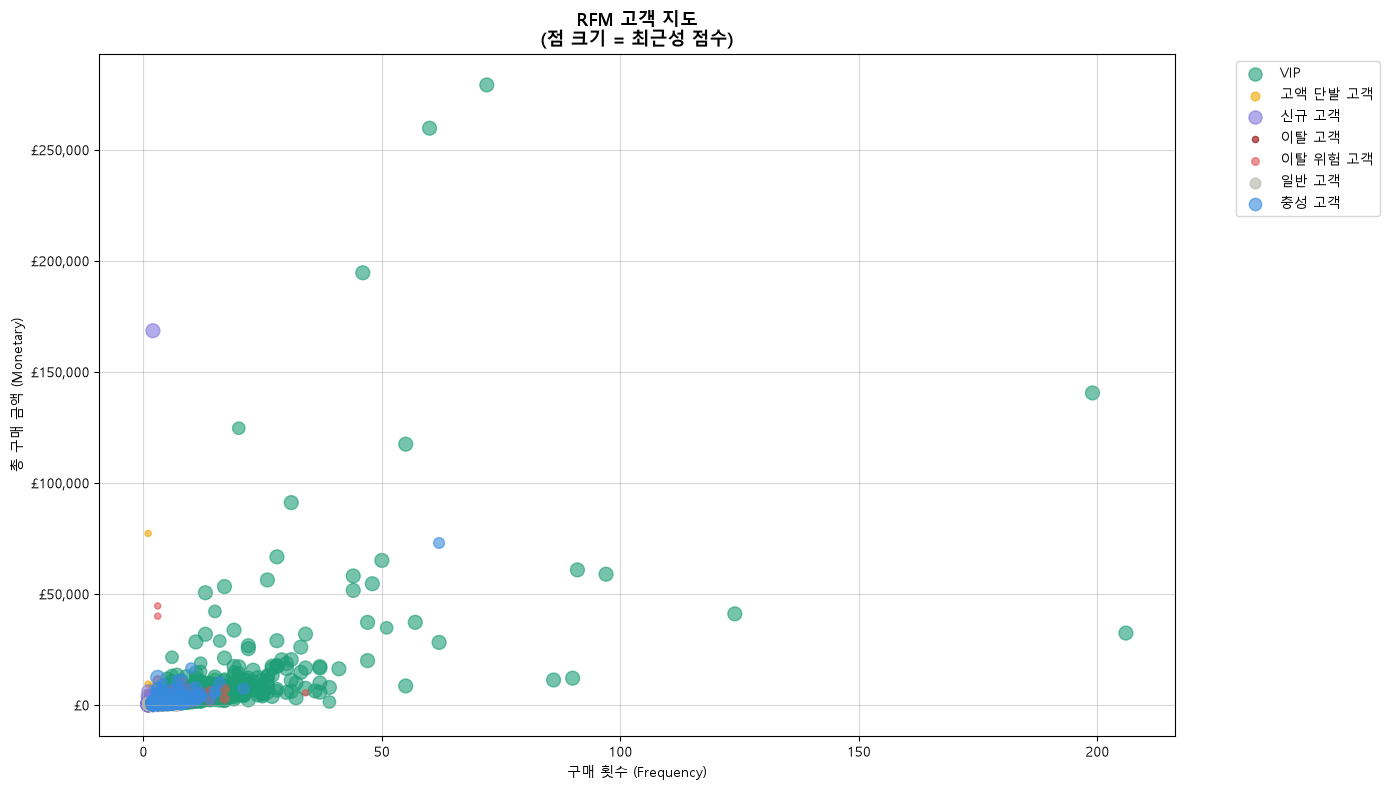

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 8))


for segment, group in df_rfm.groupby('세그먼트'):
    ax.scatter(
        group['frequency'],
        group['monetary'],
        c=colors.get(segment, '#999999'),
        label=segment,
        alpha=0.6,
        s=group['r_score'] * 20 
    )


ax.set_title('RFM 고객 지도\n(점 크기 = 최근성 점수)', 
             fontsize=13, fontweight='bold')

ax.set_xlabel('구매 횟수 (Frequency)')
ax.set_ylabel('총 구매 금액 (Monetary)')


ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)


ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


ax.grid(alpha=0.5)

plt.tight_layout()
plt.savefig('imgs/rfm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
df_rfm.to_sql("RFM", conn, if_exists="replace", index=False)

4334